In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel('Initial Public Offering.xlsx')

df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,...,426.15,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,...,199.72,34.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,...,61.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,...,1062.70,57.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,...,150.00,-5.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
columns_to_drop = [col for col in df.columns if 'Unnamed' in col]
df = df.drop(columns=columns_to_drop)
display(df.head())

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,426.85,426.15,10.87
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,201.10,199.72,34.07
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,1294.05,61.76,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,1064.60,1062.70,57.72
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,149.00,150.00,-5.70


In [ ]:
df.isnull().sum()

,0
Date,0
IPO_Name,0
Issue_Size(crores),0
QIB,2
HNI,2
RII,2
Total,2
Offer Price,0
List Price,0
Listing Gain,0


In [ ]:
df[['QIB','HNI','RII','Total']].fillna(df[['QIB','HNI','RII','Total']].median())
df['CMP(BSE)'] = df['CMP(BSE)'].fillna(df['CMP(NSE)'])
df['CMP(NSE)'] = df['CMP(NSE)'].fillna(df['CMP(BSE)'])
df.dropna(subset=['Current Gains'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Date,0
IPO_Name,0
Issue_Size(crores),0
QIB,2
HNI,2
RII,2
Total,2
Offer Price,0
List Price,0
Listing Gain,0


In [ ]:
!pip install scikit-learn

In [ ]:
print(df.shape)

(558, 13)


In [ ]:
print(df.head())

        Date                           IPO_Name  Issue_Size(crores)     QIB  \
0 2025-08-06              M & B Engineering Ltd              650.00   36.72   
1 2025-08-06  Sri Lotus Developers & Realty Ltd              792.00  163.90   
3 2025-08-05                Aditya Infotech Ltd             1300.00  133.21   
4 2025-08-05            Laxmi India Finance Ltd              254.26    1.30   
5 2025-08-01      Shanti Gold International Ltd              360.11  117.33   

      HNI    RII   Total  Offer Price  List Price  Listing Gain  CMP(BSE)  \
0   38.24  32.55   36.20          385       386.0          0.26    426.85   
1   57.71  20.28   69.14          150       179.1         19.40    201.10   
3   72.00  50.87  100.69          675      1018.0         50.81   1064.60   
4    1.84   2.22    1.87          158       136.0        -13.92    149.00   
5  151.48  30.37   81.17          199       229.1         15.13    254.00   

   CMP(NSE)  Current Gains  
0    426.15          10.87  
1   

In [ ]:
print(df['Listing Gain'].describe())

count    558.000000
mean      17.925036
std       31.931441
min      -31.730000
25%       -0.025000
50%        7.095000
75%       25.650000
max      252.760000
Name: Listing Gain, dtype: float64


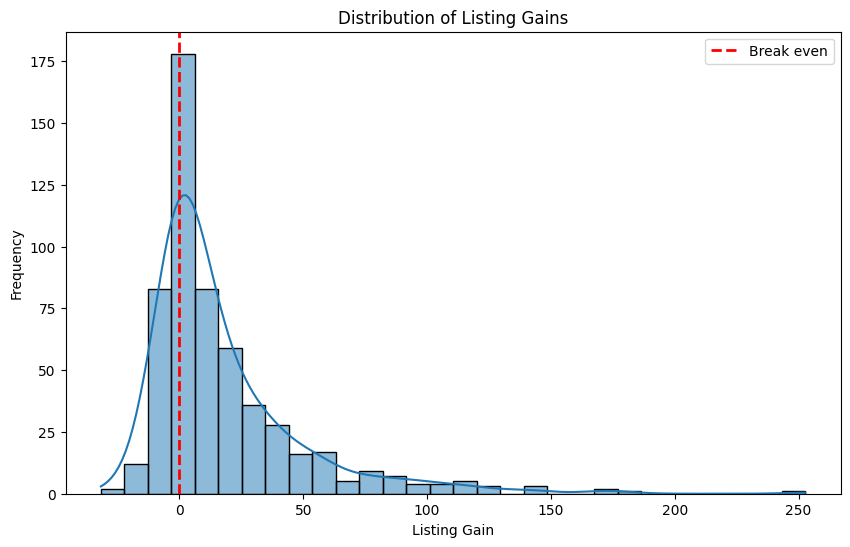

"What this distribution is telling you:\n\nMost IPOs list between 0–30% gain — that's the big cluster\nA small number are massive outliers at 150–250% — those are the ones that go viral\nNegative listings exist but are relatively rare in Indian markets"

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Listing Gain'], bins=30, kde=True)
plt.title('Distribution of Listing Gains')
plt.xlabel('Listing Gain')
plt.ylabel('Frequency')
plt.axvline(0,color='red', linestyle='--', linewidth=2, label='Break even')
plt.legend()
plt.show()

'''What this distribution is telling you:

Most IPOs list between 0–30% gain — that's the big cluster
A small number are massive outliers at 150–250% — those are the ones that go viral
Negative listings exist but are relatively rare in Indian markets'''

In [ ]:
print(df['Listing Gain'].describe())
print(f"\nIPOs listing at a loss: {(df['Listing Gain'] < 0).sum()}")
print(f"IPOs listing at 0-30%: {((df['Listing Gain'] >= 0) & (df['Listing Gain'] <= 30)).sum()}")
print(f"IPOs listing above 50%: {(df['Listing Gain'] > 50).sum()}")

count    558.000000
mean      17.925036
std       31.931441
min      -31.730000
25%       -0.025000
50%        7.095000
75%       25.650000
max      252.760000
Name: Listing Gain, dtype: float64

IPOs listing at a loss: 141
IPOs listing at 0-30%: 290
IPOs listing above 50%: 67


Out of 561 Indian IPOs from 2010–2025, 291 (52%) listed with a modest 0–30% gain, 141 (25%) listed at a loss, and only 68 (12%) delivered above 50% gains. This confirms that big listing gains are the exception, not the rule — making prediction genuinely useful for retail investors.

In [ ]:
print(df[df['Listing Gain'] > 100]['IPO_Name'].values)
print(f"\nCount: {(df['Listing Gain'] > 100).sum()}")

['Mamata Machinery Limited' 'KRN Heat Exchanger and Refrigeration Limited'
 'Bajaj Housing Finance Limited' 'Premier Energies Limited'
 'Unicommerce eSolutions Limited' 'Vibhor Steel Tubes Limited'
 'BLS E-Services Limited' 'Tata Technologies Limited'
 'Latent View Analytics' 'Sigachi Industries Limited'
 'Paras Defence and Space Technologies Limited'
 'G R Infraprojects Limited' 'Chemcon Speciality Chemicals Ltd'
 'Route Mobile Ltd' 'Happiest Minds Technologies Ltd'
 'Indian Railway Catering and Tourism Corporation Ltd'
 'Astron Paper & Board Mill Ltd' 'Salasar Techno Engineering Ltd'
 'Avenue Supermarts Ltd (DMart)']

Count: 19


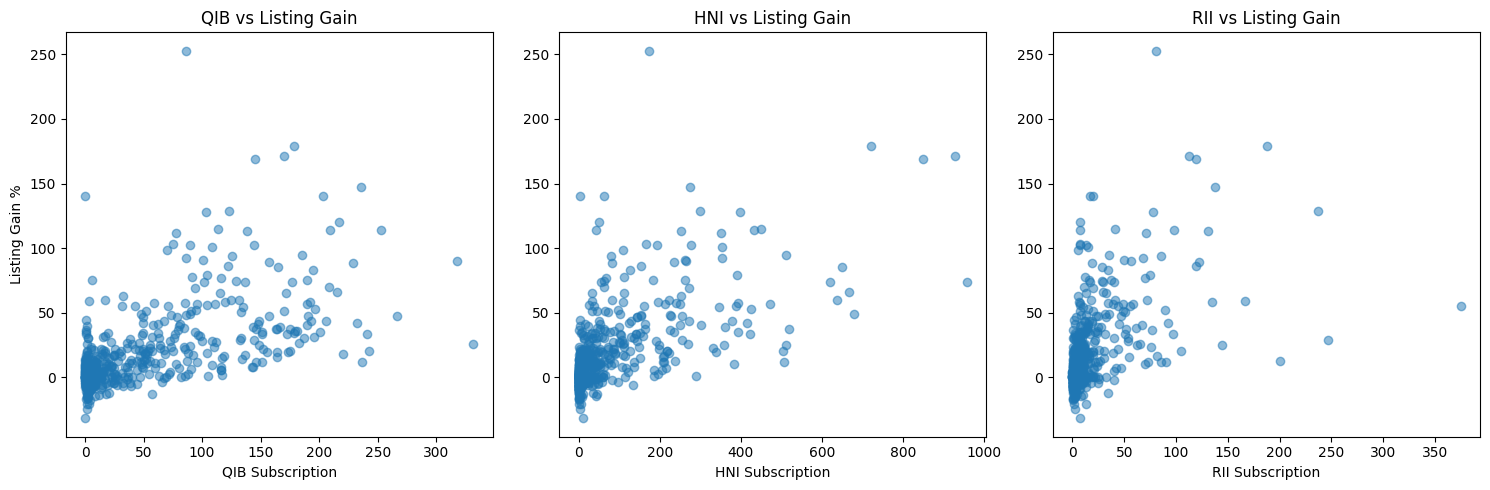

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df['QIB'], df['Listing Gain'], alpha=0.5)
axes[0].set_xlabel('QIB Subscription')
axes[0].set_ylabel('Listing Gain %')
axes[0].set_title('QIB vs Listing Gain')

axes[1].scatter(df['HNI'], df['Listing Gain'], alpha=0.5)
axes[1].set_xlabel('HNI Subscription')
axes[1].set_title('HNI vs Listing Gain')

axes[2].scatter(df['RII'], df['Listing Gain'], alpha=0.5)
axes[2].set_xlabel('RII Subscription')
axes[2].set_title('RII vs Listing Gain')

plt.tight_layout()
plt.show()

<Axes: >

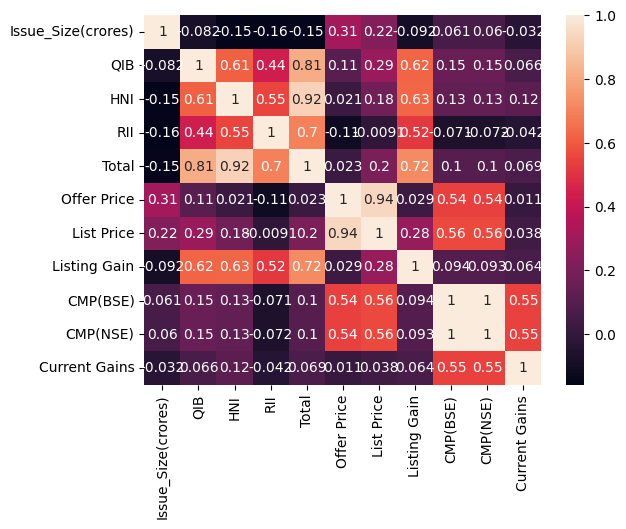

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

In [ ]:
df = df.drop(columns=['List Price', 'Total', 'CMP(BSE)', 'CMP(NSE)', 'Current Gains', 'IPO_Name'])

In [ ]:
df.columns

Index(['Date', 'Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Offer Price',
       'Listing Gain'],
      dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df = df.drop(columns=['Date'])

print(df.columns)
print(df.shape)

Index(['Issue_Size(crores)', 'QIB', 'HNI', 'RII', 'Offer Price',
       'Listing Gain', 'Month', 'Year'],
      dtype='object')
(558, 8)


In [ ]:
import yfinance as yf

nifty = yf.download('^NSEI', start='2010-01-01', end='2025-12-31')

/tmp/ipykernel_939/1429568626.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', start='2010-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed


In [ ]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


In [ ]:
df_original = pd.read_excel("Initial Public Offering.xlsx")
df['Date'] = pd.to_datetime(df_original['Date'])

nifty_close = nifty['Close']

def get_nifty_return(date):
    try:
        end_price = nifty_close.asof(date)
        start_price = nifty_close.asof(date - pd.Timedelta(days=14))
        return ((end_price - start_price) / start_price * 100).iloc[0]
    except:
        return None

df['Nifty_14d_Return'] = df['Date'].apply(get_nifty_return)
df = df.drop(columns=['Date'])

print(df.head())
print(df.isnull().sum())

   Issue_Size(crores)     QIB     HNI    RII  Offer Price  Listing Gain  \
0              650.00   36.72   38.24  32.55          385          0.26   
1              792.00  163.90   57.71  20.28          150         19.40   
3             1300.00  133.21   72.00  50.87          675         50.81   
4              254.26    1.30    1.84   2.22          158        -13.92   
5              360.11  117.33  151.48  30.37          199         15.13   

   Month  Year  Nifty_14d_Return  
0      8  2025         -2.560284  
1      8  2025         -2.560284  
3      8  2025         -1.641400  
4      8  2025         -1.641400  
5      8  2025         -1.614244  
Issue_Size(crores)    0
QIB                   2
HNI                   2
RII                   2
Offer Price           0
Listing Gain          0
Month                 0
Year                  0
Nifty_14d_Return      4
dtype: int64


In [ ]:
df[['QIB', 'HNI', 'RII']] = df[['QIB', 'HNI', 'RII']].fillna(df[['QIB', 'HNI', 'RII']].median())
df['Nifty_14d_Return'] = df['Nifty_14d_Return'].fillna(df['Nifty_14d_Return'].median())

print(df.isnull().sum())
print(df.shape)

Issue_Size(crores)    0
QIB                   0
HNI                   0
RII                   0
Offer Price           0
Listing Gain          0
Month                 0
Year                  0
Nifty_14d_Return      0
dtype: int64
(558, 9)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_sorted = df.sort_values('Year')

split_index = int(len(df_sorted) * 0.8)

x = df_sorted.drop(columns=['Listing Gain'])
y = df_sorted['Listing Gain']

x_train, x_test = x.iloc[:split_index], x.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"Train size: {len(x_train)}, Test size: {len(x_test)}")

Train size: 446, Test size: 112


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 31.43
MAE: 21.62
R²: 0.12


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = xgb.XGBRegressor(objective='reg:squarederror',
    n_estimators=90,
    max_depth=5,
    learning_rate=0.01,
    random_state=42)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 27.170
R²: 0.342


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 32.77
R²: 0.04


In [ ]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1)
model_ridge.fit(x_train, y_train)
y_pred_ridge = model_ridge.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 31.43
R²: 0.12


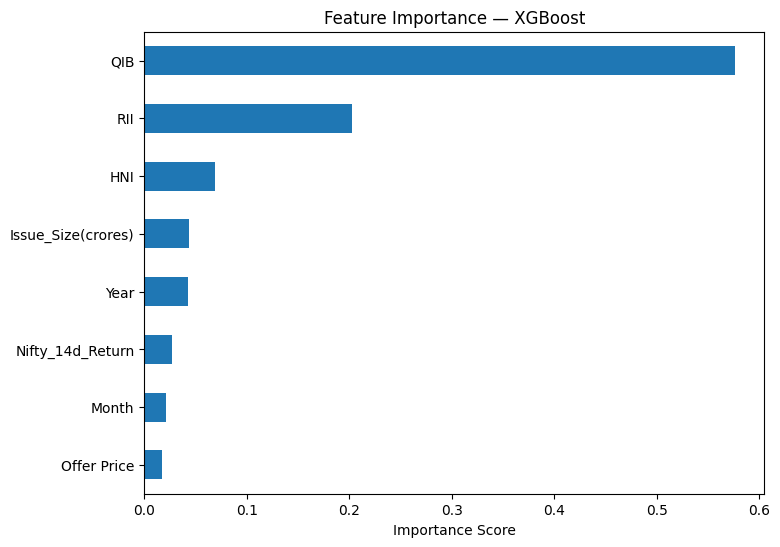

In [ ]:
#finding which feature/column is most important
import matplotlib.pyplot as plt

feat_imp = pd.Series(model.feature_importances_, index=x.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'ipo_model.pkl')

['ipo_model.pkl']